# Logistic Regression

In [22]:
from typing import Optional, Optional, Union
import pandas as pd
from sklearn.calibration import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import (
    confusion_matrix, 
    ConfusionMatrixDisplay,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    explained_variance_score,
    r2_score,
    roc_curve,
    auc
)
from sklearn.model_selection import GridSearchCV

import numpy as np

# Read dataset
data = pd.read_csv("data/dataset.csv")

# Dataset columns by type for preprocessing
binary_cols = [
    "is_driver",
    "is_public_holiday",
    "is_weekday"
]
gender_cols = ["gender"]
time_col = ["time_of_day"]
severity_col = ["severity"]
numeric = ["age", "temperature_2m", "precipitation", "windspeed_10m", "cloud_cover", "hour", "day", "month", "year"]
one_hot_cols = ["vehicle_type", "accident_type"]

# Preprocessors
gender_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OrdinalEncoder(categories=[["male", "female", "unknown"]], dtype=int))
])

time_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OrdinalEncoder(categories=[["morning", "afternoon", "evening", "night", "unknown"]], dtype=int))
])
severity_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OrdinalEncoder(categories=[["none", "minor", "serious", "fatal", "unknown"]], dtype=int))
])

binary_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
])

numeric_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

one_hot_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

results = {}

# Hyperparameter tuning helper functions
def get_best_classifier(pipeline, x_train, y_train, param_grid = None):
    if param_grid is None:
        param_grid = [
            # L2 penalty
            {
                "classifier__solver": ["lbfgs"],
                "classifier__penalty": ["l2"],
                "classifier__C": [0.01, 0.1, 1, 10]
            },
            # L1 penalty
            {
                "classifier__solver": ["liblinear"],
                "classifier__penalty": ["l1"],
                "classifier__C": [0.01, 0.1, 1, 10]
            }
        ]

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1
    )

    grid_search.fit(x_train, y_train)

    print("Best parameters:")
    print(grid_search.best_params_)
    return grid_search.best_estimator_

def display_roc_curve(y_test, y_proba, n_classes, label: Optional[Union[str, list[str]]]=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    results = {}

    # If binary classification
    if n_classes == 2:
        # If y_proba is (n_samples, 2), take positive class
        if y_proba.ndim == 2:
            y_score = y_proba[:, 1]
        else:
            y_score = y_proba

        fpr, tpr, thresholds = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)

        label = label if label else "Positive class"

        ax.plot(
            fpr,
            tpr,
            label=f"{label} (AUC = {roc_auc:.3f})"
        )
        
        results["binary"] = {
            "fpr": fpr.tolist(),
            "tpr": tpr.tolist(),
            "thresholds": thresholds.tolist(),
            "roc_auc": float(roc_auc),
            "label": label
        }
    else:
        fpr = {}
        tpr = {}
        roc_auc = {}

        y_test_bin = label_binarize(y_test, classes=range(n_classes))

        if label is None:
            label = [f"Class {i}" for i in range(n_classes)]
            
        results["multiclass"] = {}

        for i in range(n_classes):
            fpr[i], tpr[i], thresholds = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            
            results["multiclass"][label[i]] = {
                "fpr": fpr[i].tolist(),
                "tpr": tpr[i].tolist(),
                "thresholds": thresholds.tolist(),
                "roc_auc": float(roc_auc[i]),
                "label": label[i]
            }

            ax.plot(
                fpr[i],
                tpr[i],
                label=f"{label[i]} (AUC = {roc_auc[i]:.3f})"
            )

    ax.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC = 0.5)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")
    ax.legend()

    return fig, ax, results

# 1) What features predict accident severity?

In [23]:
results["question_1"] = {}

x_preprocessor = ColumnTransformer(
    transformers=[
        ("gender", gender_encoder, gender_cols),
        ("time_of_day", time_encoder, time_col),
        ("binary", binary_encoder, binary_cols),
        ("numeric", numeric_encoder, numeric),
        ("one_hot", one_hot_encoder, one_hot_cols)
    ]
)

y_preprocessor = ColumnTransformer(
    transformers=[
        ("severity", severity_encoder, severity_col),
    ]
)

classifier = LogisticRegression(max_iter=1000, random_state=42)

pipeline = Pipeline([
    ("preprocessor", x_preprocessor),
    ("classifier", classifier)
])

# Remove unknown severities
severity_data = data[~pd.isna(data["severity"])]

vals = severity_data.drop(columns=["severity"])
target = severity_data[severity_col]

y = severity_encoder.fit_transform(target.values.reshape(-1, 1)).ravel()

x_train, x_test, y_train, y_test = train_test_split(vals, y, test_size=0.2, stratify=y, random_state=42)

In [24]:
best_pipeline = get_best_classifier(pipeline, x_train, y_train)

best_pipeline.fit(x_train, y_train)

y_pred = best_pipeline.predict(x_test)
print(classification_report(y_test, y_pred, target_names=["none", "minor", "serious", "fatal"]))
results["question_1"]["classification_report"] = classification_report(y_test, y_pred, target_names=["none", "minor", "serious", "fatal"], output_dict=True)

Best parameters:
{'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
              precision    recall  f1-score   support

        none       0.67      0.80      0.73        56
       minor       0.33      0.11      0.17         9
     serious       0.64      0.76      0.70        51
       fatal       0.50      0.06      0.11        17

    accuracy                           0.65       133
   macro avg       0.54      0.43      0.43       133
weighted avg       0.61      0.65      0.60       133



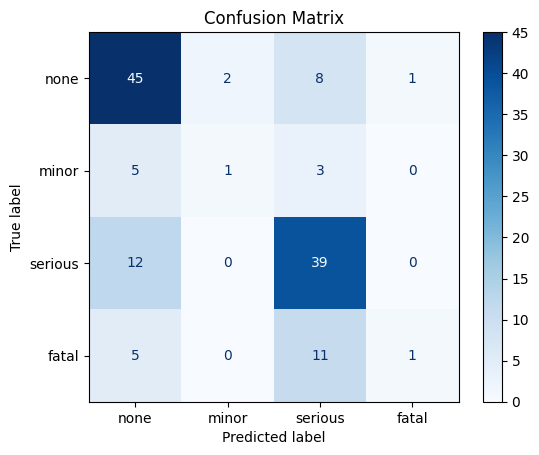

In [25]:
labels = ["none", "minor", "serious", "fatal"]
ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    x_test,
    y_test,
    display_labels=labels,
    cmap="Blues",
)
plt.title("Confusion Matrix")
plt.show()

cm = confusion_matrix(y_test, best_pipeline.predict(x_test))

# Convert to dict
results["question_1"]["confusion_matrix"] = {
    "labels": labels,
    "matrix": cm.tolist()
}

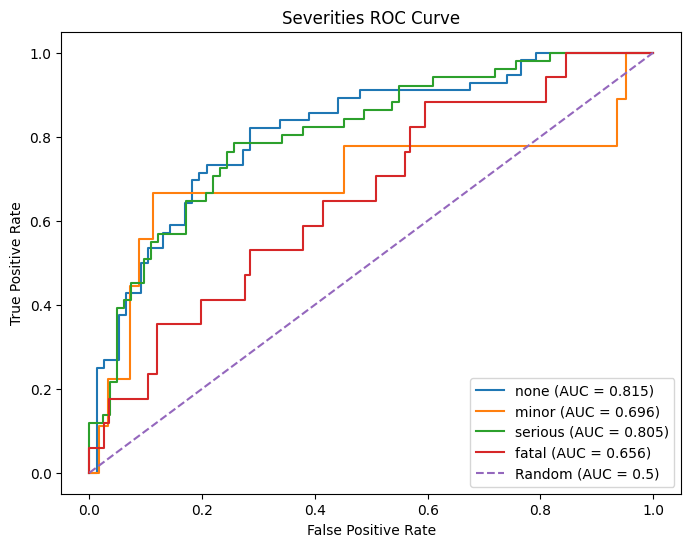

In [26]:
n_classes = len(np.unique(y_test))

y_proba = best_pipeline.predict_proba(x_test)

fig, ax, roc_results = display_roc_curve(y_test, y_proba, n_classes, label=["none", "minor", "serious", "fatal"])
ax.set_title("Severities ROC Curve")
plt.show()

results["question_1"]["roc_curve"] = roc_results

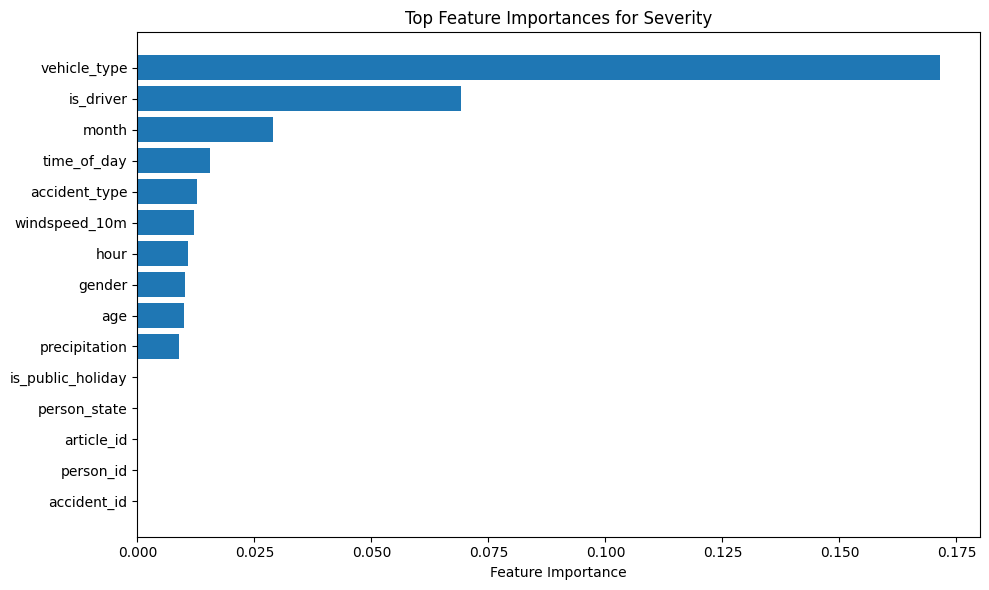

In [27]:
from sklearn.inspection import permutation_importance


feature_names = x_test.columns.tolist()
r = permutation_importance(
    best_pipeline,
    x_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_weighted"
)

importances = r.importances_mean

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

top_feats = importance_df.head(15)

# Plot top feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_feats["feature"], top_feats["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top Feature Importances for Severity")
plt.tight_layout()
plt.show()

results["question_1"]["feature_importances"] = importance_df.to_dict(orient="records")

# Interpretation
## Overall Performance
- The model achieves 65% accuracy and a 0.60 weighted F1 score, which is better than random guessing (25%) for a 4-class classification task. This indicates moderate overall performance.
- Classwise behaviour:
    - None - Strong performance (F1 = 0.73, recall = 0.80). This class is well learned, likely due to being the most frequent class (56 samples).
    - Serious – Also well learned (F1 = 0.70, recall = 0.76), benefiting from high representation (51 samples).
    - Minor – Poor performance (F1 = 0.17, recall = 0.11). This class is heavily underrepresented (9 samples), leading to weak discrimination.
    - Fatal – High precision (0.50) but extremely low recall (0.06), meaning the model is conservative: it predicts fatal accidents rarely, but is often correct when it does.
- Overall, the model is effective at separating low vs high severity outcomes, but struggles with fine-grained severity distinctions, particularly for rare classes.

## Confusion Matrix
- Fatal and Serious confusion is common, with many fatal cases misclassified as serious.
- None and Serious confusion also occurs, most likely due to being the two most represented classes.
- Minor accidents are frequently misclassified as either none or serious, suggesting they lie in an ambiguous middle ground.
- **Implication:** Accident severity is inherently continuous, but the model is trained with discrete labels, which naturally leads to boundary confusion between adjacent classes.

## ROC Curve
- None (AUC = 0.815) and Serious (AUC = 0.805) show strong separability, confirming that the model ranks these classes well against the rest.
- Minor (AUC = 0.696) shows moderate ranking ability, consistent with its weak classification metrics.
- Fatal (AUC = 0.656) is the weakest, reflecting limited signal and class imbalance.
- **Key takeaway:** Despite low recall, the model is reasonably good at ranking fatal accidents higher than non-fatal ones, which is valuable for risk prioritisation.

## Feature Importance
- Top Features:
    1. Vehicle type (dominant predictor by a large margin)
    2. Is driver
    3. Month
    4. Time of day
    5. Accident type
- Weather features (wind speed, precipitation) contribute modestly.
- Demographic features (age, gender) have relatively low importance.
- **Implication:** Contextual and situational factors are more predictive of injury severity than individual demographics.

# 2. Can we predict accident occurrence from weather variables?

In [28]:
from datetime import datetime
import requests


results["question_2"] = {}

url = "https://archive-api.open-meteo.com/v1/archive"

weather_cols = ["temperature_2m", "precipitation", "windspeed_10m", "cloud_cover", "weather_code"]
accident_cols = ["accident_id", "date_time"] + weather_cols
# Aggregate weather data per accident
weather_accident_df = data[accident_cols].groupby("accident_id").aggregate(
    {
        "accident_id": "first",
        "date_time": "first",
        **{col: "mean" for col in weather_cols}
    }
)
weather_accident_df["date"] = pd.to_datetime(weather_accident_df["date_time"]).dt.date

# Get daily accident counts
daily_accidents = (
    weather_accident_df
    .groupby("date")
    .size()
    .reset_index(name="num_accidents")
)

# Binary target
daily_accidents["accident_occurred"] = True

# Getting weather data for missing days from Open-Meteo API
accident_dts = pd.to_datetime(weather_accident_df["date_time"])
start_date = accident_dts.min()
end_date = accident_dts.max()

start_date_str = start_date.strftime("%Y-%m-%d")
end_date_str = end_date.strftime("%Y-%m-%d")

params = {
    "longitude": 14.2135424,
    "latitude": 35.935316,
    "start_date": start_date_str,
    "end_date": end_date_str,
    "hourly": ",".join(weather_cols),
    "timezone": "Europe/Malta"
}
r = requests.get(url, params=params)
weather_data = r.json()

# Create DataFrame from weather data
weather_hourly_df = pd.DataFrame({
    "date_time": pd.to_datetime(weather_data["hourly"]["time"]),
    "temperature_2m": weather_data["hourly"]["temperature_2m"],
    "precipitation": weather_data["hourly"]["precipitation"],
    "windspeed_10m": weather_data["hourly"]["windspeed_10m"],
    "cloud_cover": weather_data["hourly"]["cloud_cover"],
    "weather_code": weather_data["hourly"]["weather_code"],
})

# Aggregate daily weather data
weather_hourly_df["date"] = weather_hourly_df["date_time"].dt.date
daily_weather = (
    weather_hourly_df
    .groupby("date")
    .aggregate({
        "temperature_2m": "mean",
        "precipitation": "mean",
        "windspeed_10m": "mean",
        "cloud_cover": "mean",
        "weather_code": "mean"
    })
    .reset_index()
)

# Add missing days
daily_df = daily_weather.merge(
    daily_accidents[["date", "num_accidents", "accident_occurred"]],
    on="date",
    how="left"
)
# Fill missing values
daily_df["accident_occurred"] = daily_df["accident_occurred"].fillna(False)
daily_df["num_accidents"] = daily_df["num_accidents"].fillna(0).astype(int)

C:\Users\alang\AppData\Local\Temp\ipykernel_53964\3532061111.py:83: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  daily_df["accident_occurred"] = daily_df["accident_occurred"].fillna(False)


In [29]:
x_preprocessor = ColumnTransformer(
    transformers=[
        ("weather", numeric_encoder, ["temperature_2m", "precipitation", "windspeed_10m", "cloud_cover"]),
    ]
)

classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", x_preprocessor),
    ("classifier", classifier)
])

In [30]:
vals = daily_df
target = daily_df[["accident_occurred"]]

x_train, x_test, y_train, y_test = train_test_split(vals, target, test_size=0.2, stratify=target, random_state=42)

best_pipeline = get_best_classifier(pipeline, x_train, y_train)

best_pipeline.fit(x_train, y_train)

y_pred = best_pipeline.predict(x_test)

print(classification_report(y_test, y_pred))
results["question_2"]["classification_report"] = classification_report(y_test, y_pred, output_dict=True)

Best parameters:
{'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
              precision    recall  f1-score   support

       False       0.49      0.61      0.54        38
        True       0.50      0.38      0.43        39

    accuracy                           0.49        77
   macro avg       0.49      0.49      0.49        77
weighted avg       0.49      0.49      0.49        77



c:\Users\alang\anaconda3\envs\news-analysis\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\alang\anaconda3\envs\news-analysis\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


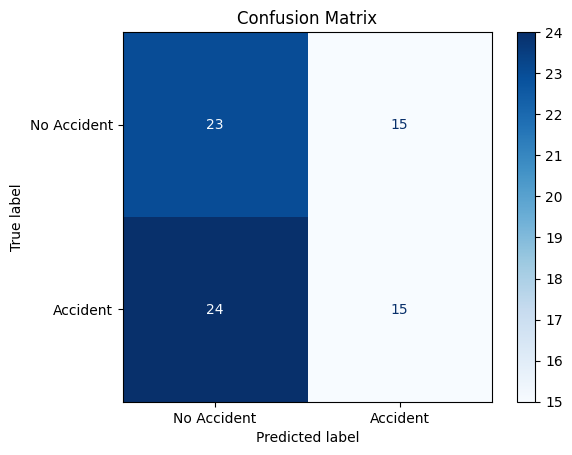

In [31]:
ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    x_test,
    y_test,
    display_labels=["No Accident", "Accident"],
    cmap="Blues",
)
plt.title("Confusion Matrix")
plt.show()

cm = confusion_matrix(y_test, best_pipeline.predict(x_test))

# Convert to dict
results["question_2"]["confusion_matrix"] = {
    "labels": ["No Accident", "Accident"],
    "matrix": cm.tolist()
}

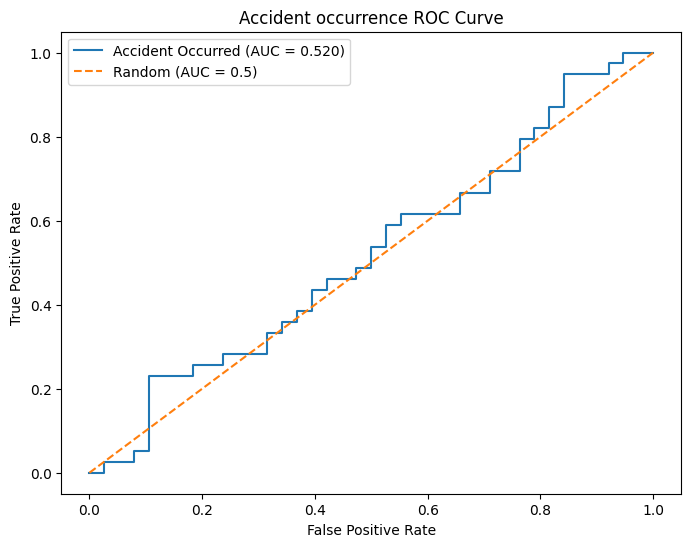

In [32]:
n_classes = len(np.unique(y_test))
y_proba = best_pipeline.predict_proba(x_test)

fig, ax, roc_results = display_roc_curve(y_test, y_proba, n_classes, label="Accident Occurred")
ax.set_title("Accident occurrence ROC Curve")
plt.show()

results["question_2"]["roc_curve"] = roc_results

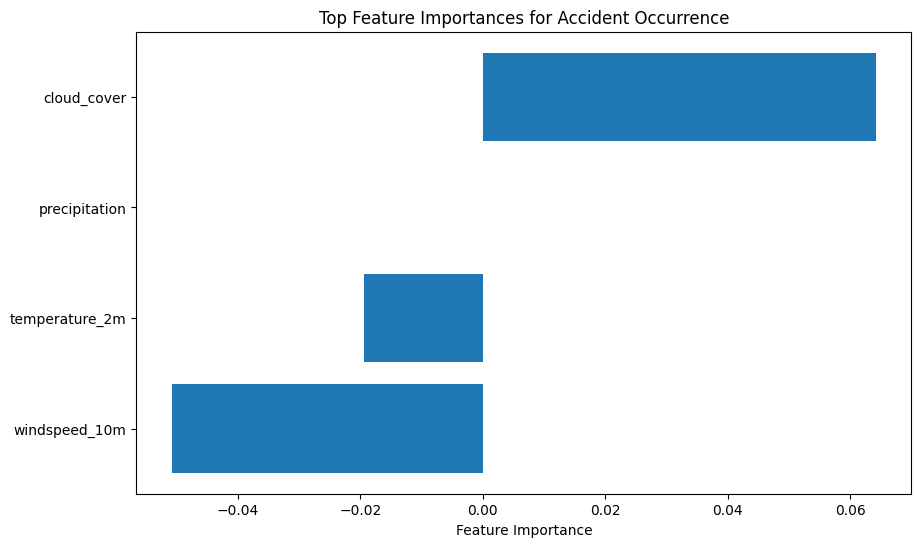

          feature  importance
4     cloud_cover    0.064287
2   precipitation    0.000000
1  temperature_2m   -0.019313
3   windspeed_10m   -0.050804


In [33]:
feature_names = x_test.columns.tolist()
r = permutation_importance(
    best_pipeline,
    x_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_weighted"
)

importances = r.importances_mean

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

included_feature_names = ["cloud_cover", "temperature_2m", "precipitation", "windspeed_10m"]
importance_df = importance_df[importance_df["feature"].isin(included_feature_names)]

top_feats = importance_df.head(15)

# Plot top feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_feats["feature"], top_feats["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top Feature Importances for Accident Occurrence")
plt.show()

results["question_2"]["feature_importances"] = importance_df.to_dict(orient="records")

print(importance_df)

# Interpretation
## Overall Performance
- Accuracy and F1 Score: The model achieves 49% accuracy with a weighted F1 score of 0.49, indicating poor performance for accident occurrence prediction. This is almost equal to random guessing (50%) for a binary classification task.
- Classwise behaviour: No Accident (False) – Moderate recall (0.61) but lower precision (0.49), meaning the model often predicts no accident, but many of these predictions are incorrect.
- Accident (True) – Low recall (0.38) with moderate precision (0.50), indicating that the model misses a large proportion of actual accident days.
- Overall, the classifier shows no meaningful discriminative ability, suggesting that weather variables alone do not capture sufficient signal for predicting accident occurrence.

## Confusion Matrix
- Approximately 50% of non-accident days are misclassified as accident days.
- More accidents are misclassified than correctly identified, as reflected by the higher false negatives relative to true positives.
- The model shows a strong bias toward predicting "No Accident", but without sufficient accuracy to be useful.
- **Implication:** The decision boundary learned by the model is weak and unstable, reflecting a lack of informative features.

## ROC Curve
- The ROC curve lies close to the diagonal, with an AUC of 0.58, indicating performance only slightly better than random.
- This confirms that the model struggles to rank accident days above non-accident days across thresholds.
- **Interpretation:** Even when threshold tuning is applied, the model provides minimal improvement over random guessing.

## Feature Importance
- Cloud cover appears as the most influential feature, followed by wind speed and temperature, though effect sizes are small.
- The presence of near-zero and negative importances suggests instability rather than meaningful causal relationships.
- **Implication:** Given the weak predictive performance, feature importance values should not be interpreted as real-world effects.

## Implications
- Weather variables alone are insufficient for predicting accident occurrence.
- While weather may influence accident risk, it must be combined with traffic volume, road characteristics, temporal context, and human factors to enable reliable prediction.
- This task likely requires richer contextual data or alternative modelling strategies, such as spatiotemporal or exposure-based approaches.

In [34]:
import json
# Save results
with open("results/log_regression_results.json", "w") as f:
    json.dump(results, f, indent=4)